# 03. Amostragem e Intervalos de Confiança

## 1. Visão Geral

Em ciência de dados, quase nunca trabalhamos com a **população completa**.  
Na maior parte dos problemas reais, temos apenas uma **amostra** dos dados disponíveis naquele momento.

Esse cenário gera uma pergunta central:

> Como estimar uma característica da população sem observar todos os seus elementos?

É exatamente aqui que entram dois conceitos fundamentais da estatística inferencial:

- **amostragem**, que representa o processo de selecionar uma parte da população;
- **intervalo de confiança**, que representa a incerteza associada à estimativa obtida com base na amostra.

Neste capítulo, usaremos **NPS** apenas como **exemplo aplicado**.  
O objetivo principal não é estudar NPS em si, mas entender como funciona o raciocínio estatístico por trás de:

1. coletar uma amostra;
2. estimar um parâmetro populacional;
3. quantificar a incerteza dessa estimativa.


## 2. Por que utilizamos amostras?

Se fosse sempre possível analisar toda a população, faríamos um **censo**.  
Na prática, isso raramente acontece, por motivos como:

- custo;
- tempo;
- dificuldade operacional;
- indisponibilidade de todos os registros no mesmo momento;
- necessidade de tomar decisão antes que todos os dados estejam disponíveis.

Por isso, usamos uma **amostra** para estimar medidas da população, como:

- média;
- proporção;
- variância;
- taxa de conversão;
- satisfação média.

### 2.1 População, parâmetro, amostra e estatística

Antes de avançar, vale separar quatro ideias:

- **população**: conjunto total de interesse;
- **parâmetro**: medida verdadeira da população;
- **amostra**: subconjunto observado da população;
- **estatística**: medida calculada a partir da amostra.

Exemplo conceitual:

- população: todos os clientes de uma empresa;
- parâmetro: média real de satisfação desses clientes;
- amostra: 80 clientes respondentes;
- estatística: média observada nesses 80 respondentes.


## 3. Exemplo prático

Para estudar esses conceitos de forma controlada, vamos criar uma **população fictícia** de notas de NPS.

A escolha do NPS é conveniente porque ele costuma apresentar características interessantes do ponto de vista estatístico:

- limite inferior e superior bem definidos;
- possível concentração em notas altas;
- presença de assimetria;
- sensibilidade a grupos com comportamentos diferentes.

### 3.1 Objetivo analítico

Nosso objetivo será responder à seguinte pergunta:

> Qual é a média populacional de NPS e qual faixa de valores plausíveis podemos atribuir a ela quando observamos apenas uma amostra?

Em outras palavras, queremos estimar a média da população e entender a **incerteza** dessa estimativa.


In [26]:
# CÉLULA 1 — IMPORTS

import numpy as np              # Biblioteca para computação numérica (arrays, álgebra, funções matemáticas)
import pandas as pd             # Manipulação de dados tabulares (DataFrames)
import matplotlib.pyplot as plt # Visualização de dados (gráficos)
from scipy import stats         # Funções estatísticas (distribuições, testes, IC, etc.)

np.random.seed(42)              # Define uma "semente" para reprodutibilidade dos resultados

In [27]:
# CÉLULA 2 — POPULAÇÃO FICTÍCIA DE NPS

# np.random.normal gera números aleatórios a partir de uma distribuição normal (gaussiana)
# Parâmetros:
# - loc: média da distribuição (μ) → onde os valores se concentram
# - scale: desvio padrão (σ) → dispersão dos dados em torno da média
# - size: quantidade de observações geradas

# Grupo de clientes satisfeitos (notas altas)
grupo_alto = np.random.normal(loc=9.2, scale=0.8, size=6000)

# Grupo intermediário
grupo_medio = np.random.normal(loc=6.5, scale=1.2, size=2500)

# Grupo insatisfeito
grupo_baixo = np.random.normal(loc=2.5, scale=1.5, size=1500)

# Junta todos os grupos em uma única população
notas = np.concatenate([grupo_alto, grupo_medio, grupo_baixo])

# Garante que os valores estejam no intervalo válido do NPS (0 a 10)
notas = np.clip(notas, 0, 10)

# Cria um DataFrame representando a população
df_pop = pd.DataFrame({"nps": notas})

df_pop.head()

,nps
0,9.597371
1,9.089389
2,9.718151
3,10.000000
4,9.012677


## 4. Conhecendo a população

Antes de falar sobre amostragem, é útil olhar para a população completa.  
Isso nos ajuda a entender qual é a “verdade” do problema e, depois, comparar essa verdade com o que a amostra consegue capturar.

### 4.1 Estatísticas descritivas da população

Vamos calcular algumas medidas importantes:

- média;
- mediana;
- desvio padrão;
- assimetria;
- curtose.

Essas métricas ajudam a resumir a distribuição antes de partirmos para a inferência.


In [28]:
# CÉLULA 3 — ESTATÍSTICAS DESCRITIVAS DA POPULAÇÃO

# Média (μ) → valor central da população
media_pop = df_pop["nps"].mean()

# Mediana → valor que divide os dados ao meio
mediana_pop = df_pop["nps"].median()

# Desvio padrão → medida de dispersão dos dados
# ddof=1 usa a fórmula amostral (n-1), mesmo sendo população simulada
desvio_pop = df_pop["nps"].std(ddof=1)

# Assimetria (skewness) → mede o grau de inclinação da distribuição
# > 0: cauda à direita | < 0: cauda à esquerda
assimetria = stats.skew(df_pop["nps"])

# Curtose → mede o peso das caudas da distribuição
# > 0: caudas pesadas (outliers mais frequentes)
# < 0: caudas leves (distribuição mais "achatada")
curtose = stats.kurtosis(df_pop["nps"])

# Exibição dos resultados
print(f"Média populacional: {media_pop:.3f}")
print(f"Mediana populacional: {mediana_pop:.3f}")
print(f"Desvio padrão populacional: {desvio_pop:.3f}")
print(f"Assimetria: {assimetria:.3f}")
print(f"Curtose: {curtose:.3f}")

Média populacional: 7.482
Mediana populacional: 8.496
Desvio padrão populacional: 2.553
Assimetria: -1.195
Curtose: 0.451


### 4.2 Histograma da população

O histograma mostra a **forma da distribuição**.  
Ele é importante porque o comportamento da população influencia diretamente:

- o desenho das amostras;
- a variabilidade das estimativas;
- a escolha do método de intervalo de confiança.

Em contextos como NPS, é comum observar mistura de perfis, o que pode gerar uma distribuição longe de uma normal perfeita.


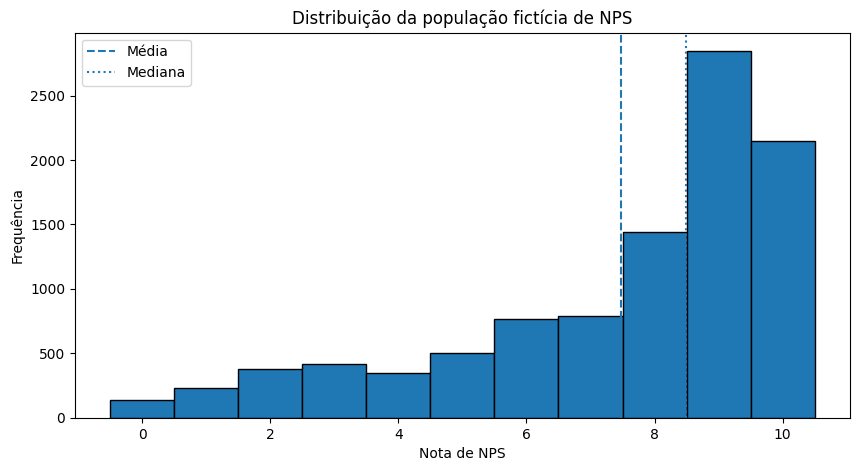

In [31]:
# CÉLULA 4 — HISTOGRAMA DA POPULAÇÃO

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Histograma da população
# bins define os intervalos das barras
# aqui usamos intervalos inteiros (0 a 10), coerente com NPS
plt.hist(
    df_pop["nps"],
    bins=np.arange(-0.5, 11.5, 1),  # bins centrados em valores inteiros
    edgecolor="black"               # borda das barras para melhor visualização
)

# Linha vertical da média
plt.axvline(media_pop, linestyle="--", label="Média")

# Linha vertical da mediana
plt.axvline(mediana_pop, linestyle=":", label="Mediana")

# Títulos e rótulos
plt.title("Distribuição da população fictícia de NPS")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

# Legenda
plt.legend()

# Renderização do gráfico
plt.show()

> **Interpretação:**
> A distribuição de NPS apresenta múltiplos picos, refletindo a existência de diferentes perfis de clientes (satisfeitos, neutros e insatisfeitos). A leve diferença entre média e mediana indica a presença de assimetria, sugerindo que os dados não seguem perfeitamente uma distribuição normal. Esse comportamento reforça a necessidade de cautela ao aplicar métodos estatísticos que assumem normalidade.

### 4.3 Boxplot, Q-Q Plot e teste de normalidade

Esses recursos ajudam a diagnosticar o comportamento da distribuição:

- **boxplot**: mostra dispersão e possíveis outliers;
- **Q-Q plot**: compara os quantis observados com os de uma normal teórica;
- **Shapiro-Wilk**: testa formalmente a hipótese de normalidade.

Esses diagnósticos não existem apenas por formalidade.  
Eles são relevantes porque alguns métodos inferenciais funcionam melhor quando certas premissas estão razoavelmente satisfeitas.


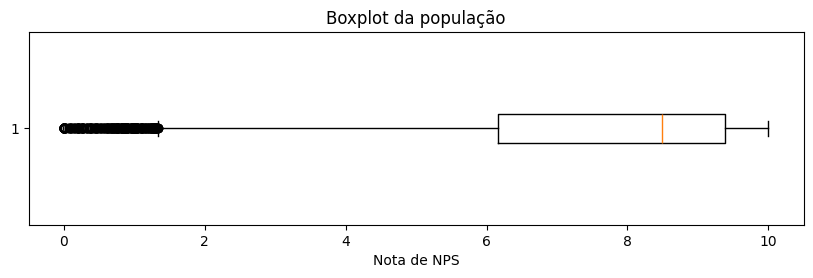

In [32]:
# CÉLULA 5 — BOXPLOT DA POPULAÇÃO

# Define o tamanho da figura
plt.figure(figsize=(10, 2.5))

# Cria o boxplot
# vert=False → deixa o gráfico horizontal (melhor para leitura em escala numérica)
plt.boxplot(df_pop["nps"], vert=False)

# Títulos e rótulos
plt.title("Boxplot da população")
plt.xlabel("Nota de NPS")

# Renderização
plt.show()

> **Interpretação:**
> O boxplot mostra que as notas de NPS apresentam uma dispersão considerável, com a mediana indicando o valor central da população. A posição da mediana dentro da caixa e o tamanho desigual dos extremos sugerem leve assimetria, reforçando que a distribuição não é perfeitamente simétrica.

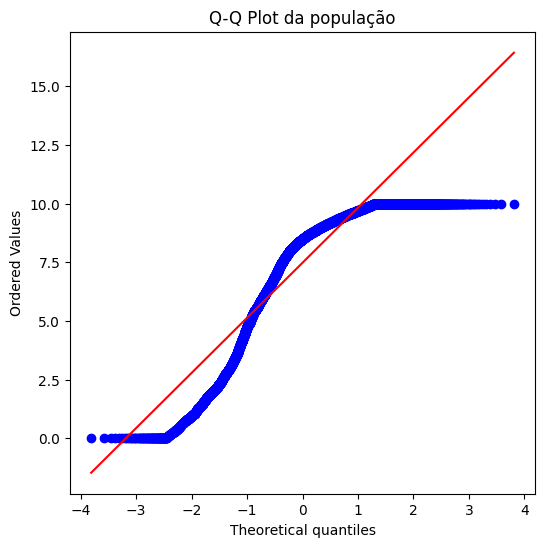

In [33]:
# CÉLULA 6 — Q-Q PLOT DA POPULAÇÃO

# Define o tamanho da figura (formato quadrado facilita a leitura da diagonal)
plt.figure(figsize=(6, 6))

# Q-Q plot (Quantile-Quantile Plot)
# Compara os quantis da amostra com os quantis de uma distribuição teórica (normal)
# dist="norm" → estamos comparando com a distribuição normal
# plot=plt → usa o matplotlib para desenhar o gráfico
stats.probplot(df_pop["nps"], dist="norm", plot=plt)

# Título do gráfico
plt.title("Q-Q Plot da população")

# Renderização
plt.show()

> **Interpretação:**
> O Q-Q plot indica que os dados não seguem perfeitamente uma distribuição normal, pois os pontos apresentam desvios da linha diagonal, especialmente nas extremidades. Esse comportamento sugere a presença de assimetria e caudas não normais, o que reforça que a população não atende completamente às premissas de normalidade.

In [34]:
# CÉLULA 7 — TESTE DE NORMALIDADE (AMOSTRA DE APOIO)

# Como o teste de Shapiro-Wilk é muito sensível a grandes volumes de dados,
# utilizamos uma subamostra para fins de diagnóstico (evita rejeições "automáticas")
amostra_shapiro = df_pop["nps"].sample(500, random_state=42)

# Aplica o teste de Shapiro-Wilk
# stat → estatística do teste
# p → p-valor associado ao teste
stat, p = stats.shapiro(amostra_shapiro)

# Exibição dos resultados
print(f"Estatística do teste: {stat:.4f}")
print(f"p-valor: {p:.6f}")

Estatística do teste: 0.8510
p-valor: 0.000000


> **Leitura correta:** se o p-valor for menor que 0,05, rejeitamos a hipótese de normalidade.  
> Isso não impede a inferência, mas indica que devemos interpretar as premissas com cuidado.

---

## 5. Processo de amostragem

Agora vamos simular o que acontece no mundo real: em vez de observar toda a população, observaremos apenas uma amostra.

### 5.1 O que uma amostra está tentando fazer?

Uma boa amostra tenta representar, de forma razoável, a população de origem.  
Ela não precisa ser idêntica à população, mas deve carregar informação suficiente para estimar seus parâmetros.

Neste exemplo, vamos usar uma **amostra aleatória simples** de 80 observações.


In [35]:
# CÉLULA 8 — AMOSTRA ALEATÓRIA

# Seleciona uma amostra aleatória da população
# n=80 → tamanho da amostra
# random_state=123 → garante reprodutibilidade da amostragem
amostra = df_pop.sample(n=80, random_state=123)

# Visualização inicial da amostra
amostra.head()

,nps
2656,8.326453
445,9.735738
9505,3.986066
332,9.260644
4168,9.989101


### 5.2 Comparando população e amostra

Uma única amostra nunca será exatamente igual à população.  
Isso é esperado.

O ponto importante é entender que existe **erro amostral**, isto é, a diferença natural entre:

- o valor verdadeiro da população;
- o valor estimado a partir da amostra.


In [36]:
# CÉLULA 9 — COMPARAÇÃO ENTRE POPULAÇÃO E AMOSTRA

print(f"Média da população: {media_pop:.3f}")
print(f"Média da amostra: {amostra['nps'].mean():.3f}")
print(f"Diferença absoluta: {abs(media_pop - amostra['nps'].mean()):.3f}")

Média da população: 7.482
Média da amostra: 7.753
Diferença absoluta: 0.271


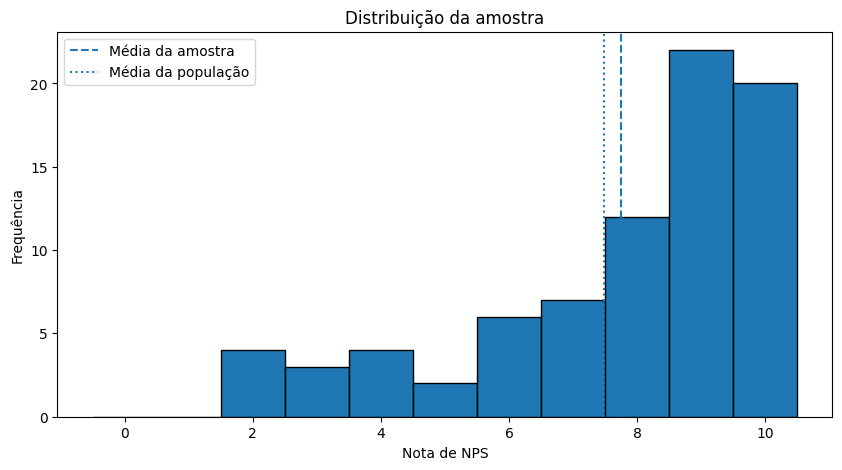

In [37]:
# CÉLULA 10 — HISTOGRAMA DA AMOSTRA

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Histograma da amostra
# bins discretos para representar corretamente as notas de NPS (0 a 10)
plt.hist(
    amostra["nps"],
    bins=np.arange(-0.5, 11.5, 1),
    edgecolor="black"
)

# Linha da média da amostra
plt.axvline(
    amostra["nps"].mean(),
    linestyle="--",
    label="Média da amostra"
)

# Linha da média da população (referência real)
plt.axvline(
    media_pop,
    linestyle=":",
    label="Média da população"
)

# Títulos e rótulos
plt.title("Distribuição da amostra")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

# Legenda
plt.legend()

# Renderização
plt.show()

> **Interpretação:**
> A distribuição da amostra apresenta maior variabilidade e irregularidade em relação à população, devido ao menor número de observações. A diferença entre a média da amostra e a média da população evidencia o erro amostral, mostrando que estimativas baseadas em uma única amostra podem não refletir exatamente o valor real da população.

## 6. Distribuição amostral da média

Aqui aparece uma das ideias mais importantes da estatística inferencial:

> se repetirmos o processo de amostragem muitas vezes, as médias das amostras também formarão uma distribuição.

Essa distribuição é chamada de **distribuição amostral da média**.

### 6.1 Por que isso importa?

Porque o intervalo de confiança é construído justamente a partir da variabilidade dessa estatística.  
Quanto mais a média amostral varia entre amostras, maior tende a ser a incerteza da estimativa.


In [39]:
# CÉLULA 11 — SIMULAÇÃO DE MÚLTIPLAS AMOSTRAS

# Lista para armazenar as médias das amostras
medias = []

# Loop para simular várias amostras
for _ in range(5000):
    
    # Seleciona uma amostra aleatória de tamanho 80
    temp = df_pop["nps"].sample(n=80)
    
    # Calcula a média da amostra e armazena
    medias.append(temp.mean())

# Converte a lista para array (facilita análises posteriores)
medias = np.array(medias)
medias

array([7.42216485, 7.43377008, 7.53994817, ..., 6.92022378, 8.04099221,
       7.49728228])

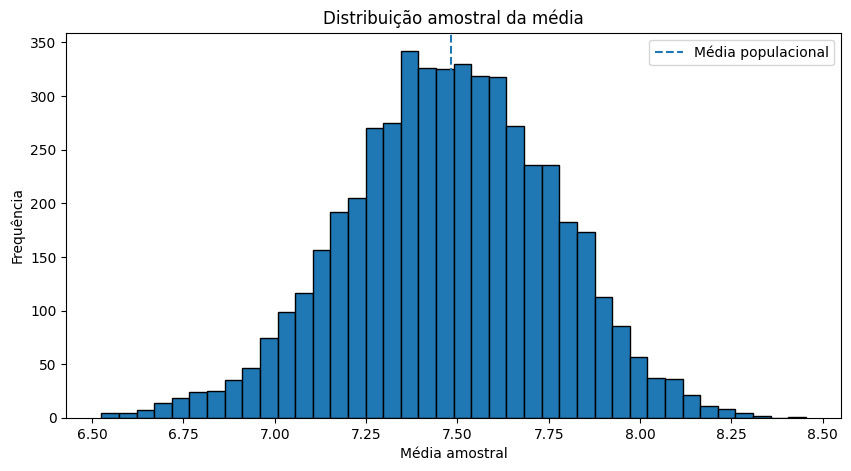

In [40]:
# CÉLULA 12 — HISTOGRAMA DAS MÉDIAS AMOSTRAIS

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Histograma das médias amostrais
# bins=40 → define a granularidade do histograma
plt.hist(
    medias,
    bins=40,
    edgecolor="black"
)

# Linha da média populacional (valor real)
plt.axvline(
    media_pop,
    linestyle="--",
    label="Média populacional"
)

# Títulos e rótulos
plt.title("Distribuição amostral da média")
plt.xlabel("Média amostral")
plt.ylabel("Frequência")

# Legenda
plt.legend()

# Renderização
plt.show()

> **Interpretação:**
> A distribuição das médias amostrais apresenta formato aproximadamente normal, mesmo com a população original não sendo perfeitamente normal. Esse comportamento ilustra o Teorema Central do Limite, indicando que a média das amostras tende a se concentrar em torno da média populacional, com menor variabilidade. Essa propriedade é fundamental para a construção de intervalos de confiança.

### 6.2 Erro padrão

O **erro padrão** mede a variabilidade da estatística amostral, especialmente da média.

Para a média amostral, ele é dado por:

$$
EP(\bar{x}) = \frac{s}{\sqrt{n}}
$$

onde:

- $s$ é o desvio padrão amostral;
- $n$ é o tamanho da amostra.

Quanto maior o tamanho da amostra, menor tende a ser o erro padrão.  
Isso ajuda a explicar por que amostras maiores produzem estimativas mais estáveis.


In [41]:
# CÉLULA 13 — EFEITO DO TAMANHO DA AMOSTRA NO ERRO PADRÃO

# Diferentes tamanhos de amostra que queremos analisar
tamanhos = [20, 50, 100, 200, 500]

# Lista para armazenar os resultados
resultado_ep = []

# Loop sobre cada tamanho de amostra
for n in tamanhos:
    
    medias_temp = []
    
    # Para cada tamanho, simulamos várias amostras
    for _ in range(2000):
        
        # Calcula a média de uma amostra de tamanho n
        medias_temp.append(df_pop["nps"].sample(n=n).mean())
    
    # Calcula o desvio padrão das médias amostrais
    # Isso é uma estimativa empírica do erro padrão
    resultado_ep.append({
        "n": n,
        "desvio_das_medias": np.std(medias_temp, ddof=1)
    })

# Converte os resultados em DataFrame
df_ep = pd.DataFrame(resultado_ep)

# Exibe os resultados
df_ep

,n,desvio_das_medias
0,20,0.580385
1,50,0.357166
2,100,0.255482
3,200,0.186740
4,500,0.111812


> À medida que $n$ cresce, a dispersão das médias amostrais tende a diminuir.  
> Esse é um dos pilares por trás da melhora de precisão em amostras maiores.

---

## 7. Intervalo de confiança

Até agora, vimos que uma amostra produz uma estimativa e que essa estimativa varia de amostra para amostra.

O próximo passo é transformar essa ideia em uma faixa de valores plausíveis para o parâmetro populacional.

### 7.1 Intuição do intervalo de confiança

Um **intervalo de confiança** não tenta adivinhar o valor exato da média populacional.  
Em vez disso, ele constrói uma **faixa plausível** ao redor da estimativa amostral.

Na prática, a lógica é:

- temos uma média amostral;
- sabemos que ela possui variabilidade;
- usamos essa variabilidade para construir uma margem de erro.

### 7.2 Quando usar t-Student?

Quando queremos estimar a média populacional e o desvio padrão populacional é desconhecido, a abordagem clássica é utilizar a distribuição **t de Student**.

Ela é especialmente importante quando trabalhamos com amostras finitas e precisamos incorporar a incerteza da estimação do desvio padrão.


In [42]:
# CÉLULA 14 — INTERVALO DE CONFIANÇA COM t-STUDENT

# Tamanho da amostra
n = len(amostra)

# Média amostral (estimativa da média populacional)
media = amostra["nps"].mean()

# Desvio padrão amostral (estima a variabilidade da população)
desvio = amostra["nps"].std(ddof=1)

# Erro padrão da média (variabilidade da média amostral)
erro_padrao = desvio / np.sqrt(n)

# Valor crítico da distribuição t
# 0.975 → corresponde a um IC de 95% (2,5% em cada cauda)
# df=n-1 → graus de liberdade
t_critico = stats.t.ppf(0.975, df=n - 1)

# Margem de erro
margem = t_critico * erro_padrao

# Limites do intervalo de confiança
ic_inf_t = media - margem
ic_sup_t = media + margem

# Exibição dos resultados
print(f"Média amostral: {media:.3f}")
print(f"Erro padrão: {erro_padrao:.3f}")
print(f"t crítico: {t_critico:.3f}")
print(f"IC 95% (t-Student): ({ic_inf_t:.3f}, {ic_sup_t:.3f})")
print(f"Média populacional real: {media_pop:.3f}")

Média amostral: 7.753
Erro padrão: 0.260
t crítico: 1.990
IC 95% (t-Student): (7.236, 8.269)
Média populacional real: 7.482


### 7.3 Interpretação correta

A interpretação prática é:

> o intervalo construído a partir da amostra fornece uma faixa plausível para a média populacional.

Um ponto importante: em linguagem estritamente frequentista, não dizemos que há “95% de probabilidade de a média populacional estar neste intervalo específico”.  
O mais correto é dizer que o **procedimento** de construção do intervalo, ao ser repetido muitas vezes, tende a capturar o parâmetro verdadeiro em 95% das amostras.

Para uso aplicado, contudo, é comum comunicar o resultado como uma **faixa de valores plausíveis**, desde que essa nuance conceitual seja conhecida.


## 8. Quando as premissas ficam frágeis?

O t-Student costuma funcionar bem em muitos contextos, mas há cenários em que devemos redobrar a atenção, como quando temos:

- amostra muito pequena;
- forte assimetria;
- presença relevante de outliers;
- indício claro de não normalidade.

Para ilustrar isso, vamos criar uma amostra pequena e propositalmente problemática.


In [43]:
# CÉLULA 15 — AMOSTRA PROBLEMÁTICA

# Criação manual de uma amostra com comportamento não representativo
# Mistura de valores muito altos com alguns extremamente baixos
# Pequeno tamanho amostral e distribuição claramente assimétrica
amostra_ruim = pd.DataFrame({
    "nps": [10, 10, 9, 10, 8, 9, 10, 9, 10, 10, 2, 1, 0, 10, 9]
})

# Visualização da amostra
amostra_ruim

,nps
0,10
1,10
2,9
3,10
4,8
5,9
6,10
7,9
8,10
9,10


### 8.1 Diagnóstico estatístico

Antes de escolher o método, precisamos diagnosticar os dados.  
A ordem correta de raciocínio é:

1. olhar o tamanho da amostra;
2. medir dispersão e assimetria;
3. inspecionar visualmente a distribuição;
4. testar normalidade com cautela.

Só depois disso faz sentido decidir entre t-Student, bootstrap ou outro procedimento.


In [44]:
# CÉLULA 16 — DIAGNÓSTICO DA AMOSTRA PROBLEMÁTICA

# Tamanho da amostra
n_ruim = len(amostra_ruim)

# Média da amostra (estimativa central)
media_ruim = amostra_ruim["nps"].mean()

# Desvio padrão amostral (variabilidade dos dados)
desvio_ruim = amostra_ruim["nps"].std(ddof=1)

# Assimetria (skewness)
# Mede o grau de inclinação da distribuição
assimetria_ruim = stats.skew(amostra_ruim["nps"])

# Curtose
# Mede o peso das caudas (presença de valores extremos)
curtose_ruim = stats.kurtosis(amostra_ruim["nps"])

# Teste de normalidade de Shapiro-Wilk
# stat → estatística do teste
# p_valor → evidência contra a normalidade
stat_ruim, p_valor = stats.shapiro(amostra_ruim["nps"])

# Exibição dos resultados
print(f"Tamanho da amostra: {n_ruim}")
print(f"Média: {media_ruim:.3f}")
print(f"Desvio padrão: {desvio_ruim:.3f}")
print(f"Assimetria: {assimetria_ruim:.3f}")
print(f"Curtose: {curtose_ruim:.3f}")
print(f"p-valor Shapiro-Wilk: {p_valor:.6f}")

Tamanho da amostra: 15
Média: 7.800
Desvio padrão: 3.590
Assimetria: -1.443
Curtose: 0.293
p-valor Shapiro-Wilk: 0.000064


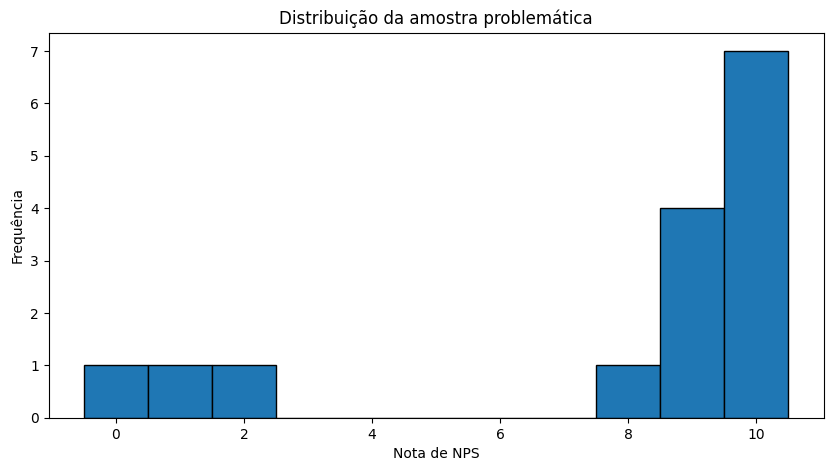

In [45]:
# CÉLULA 17 — HISTOGRAMA DA AMOSTRA PROBLEMÁTICA

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Histograma da amostra problemática
# bins discretos para representar corretamente as notas de NPS (0 a 10)
plt.hist(
    amostra_ruim["nps"],
    bins=np.arange(-0.5, 11.5, 1),
    edgecolor="black"
)

# Títulos e rótulos
plt.title("Distribuição da amostra problemática")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

# Renderização
plt.show()

> **Interpretação:**
> O histograma evidencia uma distribuição assimétrica, com forte concentração de valores altos e presença de poucos valores extremamente baixos. Essa configuração indica uma amostra instável e não representativa, reforçando a violação das premissas de normalidade e a necessidade de métodos mais robustos para inferência.

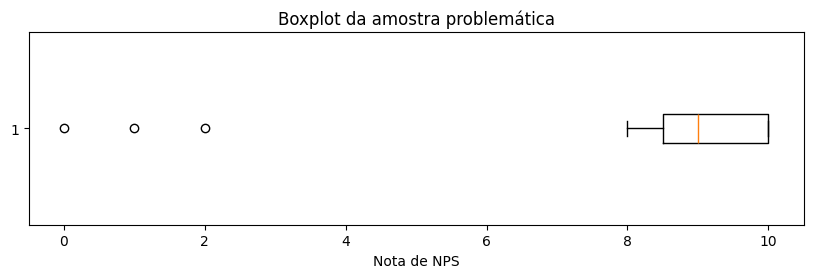

In [46]:
# CÉLULA 18 — BOXPLOT DA AMOSTRA PROBLEMÁTICA

# Define o tamanho da figura (horizontal facilita leitura da escala)
plt.figure(figsize=(10, 2.5))

# Cria o boxplot
# vert=False → orientação horizontal
plt.boxplot(amostra_ruim["nps"], vert=False)

# Títulos e rótulos
plt.title("Boxplot da amostra problemática")
plt.xlabel("Nota de NPS")

# Renderização
plt.show()

> **Interpretação:**
> O boxplot evidencia a presença de assimetria e possíveis valores extremos, com a mediana deslocada e uma cauda mais longa em direção aos valores baixos. Esse comportamento indica que poucos valores atípicos exercem forte influência sobre a distribuição, comprometendo a estabilidade das estimativas baseadas na média.

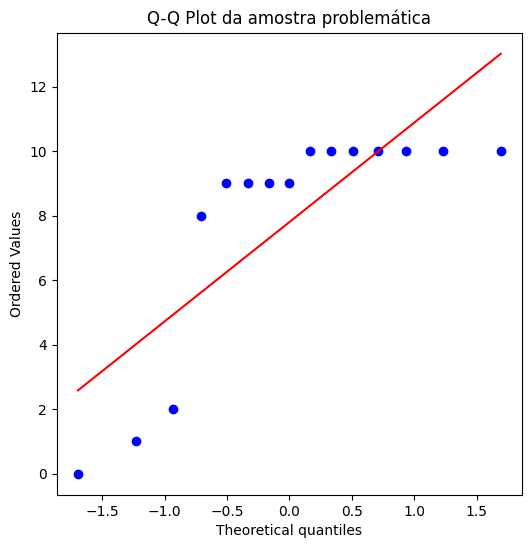

In [47]:
# CÉLULA 19 — Q-Q PLOT DA AMOSTRA PROBLEMÁTICA

# Define o tamanho da figura (formato quadrado facilita comparar com a diagonal)
plt.figure(figsize=(6, 6))

# Q-Q plot (Quantile-Quantile Plot)
# Compara os quantis observados da amostra com os quantis de uma distribuição normal
# dist="norm" → referência teórica: normal
# plot=plt → usa matplotlib para renderizar
stats.probplot(amostra_ruim["nps"], dist="norm", plot=plt)

# Título do gráfico
plt.title("Q-Q Plot da amostra problemática")

# Renderização
plt.show()

> **Interpretação:**
> O Q-Q plot evidencia desvios significativos em relação à linha diagonal, indicando que a distribuição da amostra não segue o comportamento esperado de uma distribuição normal. Os afastamentos, especialmente nas extremidades, sugerem a presença de assimetria e valores extremos, reforçando a inadequação de métodos que assumem normalidade.

**Não devemos confiar cegamente no t-Student nesse caso.**

---

## 9. Aplicando t-Student mesmo assim

Vamos calcular o intervalo com t-Student para observar o comportamento do método em um contexto menos favorável.


In [48]:
# CÉLULA 20 — IC t-STUDENT NA AMOSTRA PROBLEMÁTICA

# Tamanho da amostra
n = len(amostra_ruim)

# Média amostral
media = amostra_ruim["nps"].mean()

# Desvio padrão amostral
desvio = amostra_ruim["nps"].std(ddof=1)

# Erro padrão da média
erro_padrao = desvio / np.sqrt(n)

# Valor crítico da distribuição t (IC de 95%)
# 0.975 → 2,5% em cada cauda
# df=n-1 → graus de liberdade
t_critico = stats.t.ppf(0.975, df=n - 1)

# Margem de erro
margem = t_critico * erro_padrao

# Intervalo de confiança
ic_inf_t_ruim = media - margem
ic_sup_t_ruim = media + margem

# Exibição do resultado
print(f"IC 95% (t-Student): ({ic_inf_t_ruim:.3f}, {ic_sup_t_ruim:.3f})")

IC 95% (t-Student): (5.812, 9.788)


### 9.1 Limitação conceitual

Esse cálculo pode até ser executado matematicamente, mas a questão central é outra:

> ele é confiável o suficiente para este tipo de dado?

Quando a amostra é pequena e a distribuição é muito assimétrica, a aproximação do t-Student pode não refletir bem a incerteza real.


## 10. Bootstrap

O **bootstrap** é uma alternativa muito útil quando queremos estimar a incerteza sem depender fortemente de uma forma paramétrica específica para a distribuição.

### 10.1 Ideia do método

A lógica é simples:

1. reamostrar, com reposição, a própria amostra observada;
2. calcular a média em cada reamostra;
3. usar a distribuição dessas médias para construir o intervalo.

Na prática, o bootstrap aproxima empiricamente a distribuição amostral da estatística de interesse.


In [49]:
# CÉLULA 21 — BOOTSTRAP

# Número de reamostragens (quanto maior, melhor a aproximação)
n_boot = 10000

# Lista para armazenar as médias bootstrap
medias_boot = []

# Loop de reamostragem
for _ in range(n_boot):
    
    # Reamostragem com reposição
    # replace=True → permite repetir elementos (essencial no bootstrap)
    # n=len(amostra_ruim) → mantém o mesmo tamanho da amostra original
    reamostra = amostra_ruim["nps"].sample(
        n=len(amostra_ruim),
        replace=True
    )
    
    # Calcula a média da reamostra
    medias_boot.append(reamostra.mean())

# Converte para array para facilitar análises posteriores
medias_boot = np.array(medias_boot)
medias_boot

array([9.        , 7.86666667, 8.86666667, ..., 7.66666667, 6.66666667,
       7.46666667])

In [50]:
# CÉLULA 22 — INTERVALO DE CONFIANÇA BOOTSTRAP

# Percentil 2.5% → limite inferior do IC
ic_inf_boot = np.percentile(medias_boot, 2.5)

# Percentil 97.5% → limite superior do IC
ic_sup_boot = np.percentile(medias_boot, 97.5)

# Exibição do intervalo
print(f"IC 95% (Bootstrap): ({ic_inf_boot:.3f}, {ic_sup_boot:.3f})")

IC 95% (Bootstrap): (5.932, 9.400)


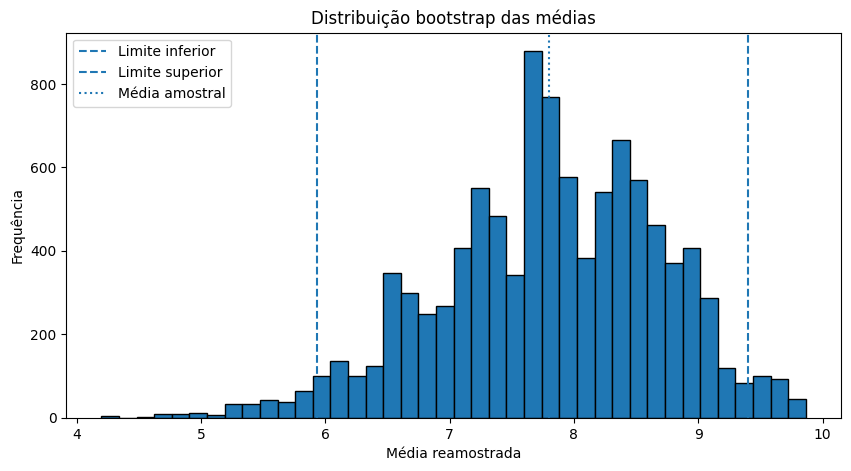

In [51]:
# CÉLULA 23 — DISTRIBUIÇÃO DAS MÉDIAS BOOTSTRAP

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Histograma das médias geradas via bootstrap
# bins=40 → granularidade da distribuição
plt.hist(
    medias_boot,
    bins=40,
    edgecolor="black"
)

# Linha do limite inferior do intervalo de confiança
plt.axvline(
    ic_inf_boot,
    linestyle="--",
    label="Limite inferior"
)

# Linha do limite superior do intervalo de confiança
plt.axvline(
    ic_sup_boot,
    linestyle="--",
    label="Limite superior"
)

# Linha da média amostral
plt.axvline(
    amostra_ruim['nps'].mean(),
    linestyle=":",
    label="Média amostral"
)

# Títulos e rótulos
plt.title("Distribuição bootstrap das médias")
plt.xlabel("Média reamostrada")
plt.ylabel("Frequência")

# Legenda
plt.legend()

# Renderização
plt.show()

> **Interpretação:**
> A distribuição das médias obtidas via bootstrap reflete o comportamento empírico da amostra, podendo apresentar assimetria e variações que não seriam capturadas por métodos baseados em normalidade. O intervalo de confiança acompanha esse formato, delimitando a região onde a média tende a se concentrar, oferecendo uma estimativa mais aderente à realidade dos dados.

## 11. Comparação entre métodos

Agora podemos comparar diretamente os dois intervalos obtidos para a amostra problemática.


In [52]:
# CÉLULA 24 — COMPARAÇÃO ENTRE t-STUDENT E BOOTSTRAP

# Cria um DataFrame comparando os dois métodos de intervalo de confiança
comparacao = pd.DataFrame({
    
    # Nome do método utilizado
    "metodo": ["t-Student", "Bootstrap"],
    
    # Limite inferior de cada intervalo
    "limite_inferior": [ic_inf_t_ruim, ic_inf_boot],
    
    # Limite superior de cada intervalo
    "limite_superior": [ic_sup_t_ruim, ic_sup_boot],
    
    # Largura do intervalo (medida de incerteza)
    # quanto maior, maior a incerteza da estimativa
    "largura": [
        ic_sup_t_ruim - ic_inf_t_ruim,
        ic_sup_boot - ic_inf_boot
    ]
})

# Exibe a tabela comparativa
comparacao

,metodo,limite_inferior,limite_superior,largura
0,t-Student,5.812108,9.787892,3.975783
1,Bootstrap,5.931667,9.400000,3.468333


### 11.1 Leitura profissional

Essa comparação mostra um ponto importante da prática analítica:

- o método estatístico não deve ser escolhido por hábito;
- ele deve ser escolhido com base nas características dos dados;
- diferentes métodos podem produzir respostas parecidas ou bem diferentes;
- quando os resultados divergem, isso é um sinal de que a estrutura da amostra merece atenção.

Em ambientes de negócio, essa diferença pode alterar a confiança da decisão.


In [25]:
# CÉLULA 25 — REGRAS SIMPLES DE DIAGNÓSTICO

n_pequeno = len(amostra_ruim) < 30
assimetria_alta = abs(assimetria_ruim) > 1
nao_normal = p_valor < 0.05

print("Amostra pequena:", n_pequeno)
print("Alta assimetria:", assimetria_alta)
print("Indício de não normalidade:", nao_normal)


Amostra pequena: True
Alta assimetria: True
Indício de não normalidade: True


## 12. Conclusões

Este capítulo mostrou que **amostragem** e **intervalo de confiança** são partes do mesmo raciocínio inferencial.

A sequência lógica é:

1. não conseguimos observar toda a população;
2. coletamos uma amostra;
3. calculamos uma estatística amostral;
4. reconhecemos que essa estatística varia de amostra para amostra;
5. construímos um intervalo para representar a incerteza dessa estimativa.

### 12.1 Resumo conceitual

- **Amostragem** existe porque quase nunca temos acesso completo à população.
- **Erro amostral** é a diferença natural entre a estimativa e o parâmetro real.
- **Distribuição amostral** explica por que a média muda quando repetimos amostras.
- **Erro padrão** quantifica a variabilidade da estatística.
- **Intervalo de confiança** transforma essa variabilidade em uma faixa plausível.
- **t-Student** é adequado em muitos cenários, mas depende de premissas razoáveis.
- **Bootstrap** é uma alternativa útil quando os dados desafiam essas premissas.

### 12.2 Regra prática

Em contexto profissional, pense assim:

- primeiro diagnostique os dados;
- depois escolha o método;
- só então interprete o intervalo.

Essa ordem evita aplicar uma técnica correta do ponto de vista algébrico, mas inadequada do ponto de vista estatístico.
